# Chapter 19: Auto-Calibration

Source orientation: PDF pages 476-519, printed pages 458-501.

This notebook is an original computational treatment of the chapter. The source pages were used to identify the chapter structure, terminology, equations, and warnings; the prose, diagrams, code, data, and artifacts below are newly authored and use deterministic synthetic measurements rather than textbook figures or page crops.


## Chapter Goal

Auto-calibration asks for metric information when the images were not taken with a calibration object. The central idea is that a rigidly moving camera must preserve the same absolute conic in 3-space. In computation this becomes a small set of inspectable objects:

- a projective reconstruction with cameras $P_i=[A_i\mid a_i]$;
- a rectifying homography $H$ whose upper block contains the first calibration matrix and whose lower row encodes the plane at infinity;
- the image of the absolute conic (IAC) $\omega=(KK^T)^{-1}$ and its dual (DIAC) $\omega^*=KK^T$;
- the dual absolute quadric (DAQ) $Q^*_\infty$, a rank-3 positive semidefinite 4 by 4 matrix whose null vector is the plane at infinity;
- pairwise Kruppa constraints and stratified infinite-homography constraints that convert image measurements into equations on $\omega$, $\omega^*$, or $Q^*_\infty$.

The chapter's practical lesson is also important: self-calibration is powerful, but critical motion sequences can leave unobservable degrees of freedom. This notebook makes those missing degrees of freedom visible as extra singular-vector null directions.


## Computational Translation Guide

| Book object | Computational object in this notebook | What must be checked |
| --- | --- | --- |
| Rectifying homography | A 4 by 4 matrix $H=\begin{bmatrix}K&0\\-p^TK&1\end{bmatrix}$ | $P_1H=[K\mid0]$ and $p$ gives the plane at infinity in the projective frame |
| DAQ $Q^*_\infty$ | `Q = H @ diag(1,1,1,0) @ H.T` | symmetric, rank 3, semidefinite up to scale, and `Q @ [p,1] == 0` |
| DIAC projection | `P @ Q @ P.T` | proportional to $K_iK_i^T$ in every view |
| Varying focal calibration | linear rows from zero principal point, zero skew, and unit aspect ratio | SVD nullspace recovers $Q^*_\infty$ up to scale |
| Kruppa equations | a proportionality between `[e']_x omega_star [e']_x` and `F omega_star F.T` | residual is near zero for a consistent constant-$K$ pair |
| Stratified metric upgrade | IAC transfer through $H_\infty=A-ap^T$ or through rotation homographies | one rotation axis leaves a two-dimensional nullspace; multiple axes reduce it to scale |
| Stereo-rig affine calibration | plane-at-infinity eigenvector of $H_P^T$ | general screw motion gives a one-dimensional nullspace; planar orthogonal motion does not |

All equalities involving homogeneous conics and quadrics are compared after removing scale. The final sanity cell asserts both artifact integrity and these geometric identities.


## Library Routing

| Concept | Representation | Library route | Why this route |
| --- | --- | --- | --- |
| DAQ, IAC, DIAC, rectifying homography | dense homogeneous matrices and SVD nullspaces | NumPy and SciPy | the chapter is mainly linear algebra over projective coordinates; SciPy Cholesky recovers $K$ from the IAC |
| Camera rotations and fundamental matrices | Rodrigues vectors, camera matrices, skew matrices | OpenCV plus NumPy | Rodrigues vectors are standard in camera calibration workflows and keep the rotation examples concrete |
| Constraint rank and degeneracy | singular-value spectra and nullity tables | NumPy, Pandas, Matplotlib | degeneracies are most inspectable as rank loss, not as a decorative scene |
| Kruppa tangency | schematic conic, epipole, and tangent-line transfer | Matplotlib | the geometry is planar and incidence based; a static labeled construction is the clearest artifact |
| Varying focal length | interactive residual curves over focal candidates | Plotly | the learner can hover on the residual minima and compare them with the true per-view focal lengths |
| Symbolic DAQ null identity | exact expression for $Q^*_\infty[p,1]^T=0$ | SymPy | the null-vector property is a short algebraic invariant worth proving exactly |


## Chapter-Specific Storyboard

1. **Absolute conic and DAQ scaffold.** Build a projective reconstruction by applying a known rectifying homography backward to metric cameras. Show that the DAQ is rank 3, that its null vector is the plane at infinity, and that it projects to each view's DIAC.
2. **Self-calibration constraints as rows of a linear system.** Use the varying-focal case with known principal point, zero skew, and known aspect ratio. Each camera contributes the entries that must vanish or agree in the projected DIAC. The artifact shows the SVD spectrum and the recovered focal lengths.
3. **Kruppa as epipolar tangency.** Draw the tangent-line picture and verify the algebraic proportionality for a synthetic constant-calibration camera pair. The visual emphasizes that Kruppa works with dual conics and is weaker than a known infinite homography.
4. **Stratified IAC upgrade and ambiguity.** Treat rotation-only homographies as directly measured infinite homographies. Compare one-axis rotation with rotations about multiple axes; the extra null direction is the one-parameter ambiguity.
5. **Stereo-rig plane-at-infinity eigenvector.** Conjugate a Euclidean screw motion into a projective frame and recover the plane at infinity from $H_P^T-I$. Repeat with planar orthogonal motion to expose the degeneracy.
6. **Applied lab.** Perturb the synthetic constraints and record which checks fail smoothly and which fail abruptly. The lab is small, but it mirrors the chapter's practical recommendation: inspect conditioning before trusting a calibration.


In [1]:
from pathlib import Path
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the MVG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-19"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)


In [2]:
import math

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from scipy.linalg import cholesky

from utils.artifacts import assert_artifacts, display_artifact, save_csv, save_json, save_matplotlib, save_plotly_html

np.set_printoptions(precision=4, suppress=True)
artifact_paths = []
check_data = {}


def calibration_matrix(fx, fy=None, cx=0.0, cy=0.0, skew=0.0):
    if fy is None:
        fy = fx
    return np.array([[fx, skew, cx], [0.0, fy, cy], [0.0, 0.0, 1.0]], dtype=float)


def rodrigues(axis, angle):
    axis = np.asarray(axis, dtype=float)
    axis = axis / np.linalg.norm(axis)
    return cv2.Rodrigues(axis * angle)[0]


def camera_matrix(K, R, t):
    return K @ np.hstack([R, np.asarray(t, dtype=float).reshape(3, 1)])


def rectifier_from_plane_and_K(K, p):
    H = np.eye(4)
    H[:3, :3] = K
    H[3, :3] = -(np.asarray(p, dtype=float) @ K)
    return H


def dual_absolute_quadric(H):
    return H @ np.diag([1.0, 1.0, 1.0, 0.0]) @ H.T


def skew(v):
    x, y, z = np.asarray(v, dtype=float).reshape(3)
    return np.array([[0.0, -z, y], [z, 0.0, -x], [-y, x, 0.0]], dtype=float)


def normalize_scale(M):
    M = np.asarray(M, dtype=float)
    n = np.linalg.norm(M)
    return M / n if n else M


def camera_center(P):
    _, _, vt = np.linalg.svd(P)
    C = vt[-1]
    return C / C[-1]


def enforce_rank2(F):
    u, s, vt = np.linalg.svd(F)
    s[-1] = 0.0
    return normalize_scale(u @ np.diag(s) @ vt)


def fundamental_from_cameras(P1, P2):
    C1 = camera_center(P1)
    e2 = P2 @ C1
    return enforce_rank2(skew(e2) @ P2 @ np.linalg.pinv(P1))


def right_null(A):
    _, _, vt = np.linalg.svd(A)
    x = vt[-1]
    if abs(x[-1]) > 1e-12:
        return x / x[-1]
    return x / np.linalg.norm(x)


def proportional_residual(A, B):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    scale = np.sum(A * B) / max(np.sum(B * B), 1e-30)
    residual = np.linalg.norm(A - scale * B) / max(np.linalg.norm(A), 1e-30)
    return float(residual), float(scale)


q_pairs = [(i, j) for i in range(4) for j in range(i, 4)]


def qvec(Q):
    return np.array([Q[i, j] for i, j in q_pairs], dtype=float)


def qmat(x):
    Q = np.zeros((4, 4), dtype=float)
    for value, (i, j) in zip(x, q_pairs):
        Q[i, j] = Q[j, i] = value
    return Q


def projected_conic_coeff(P, a, b):
    row = []
    for i, j in q_pairs:
        coeff = P[a, i] * P[b, j]
        if i != j:
            coeff += P[a, j] * P[b, i]
        row.append(coeff)
    return np.asarray(row, dtype=float)


def varying_focal_constraint_rows(P):
    # Principal point at origin, zero skew, known unit aspect ratio.
    return np.vstack([
        projected_conic_coeff(P, 0, 2),
        projected_conic_coeff(P, 1, 2),
        projected_conic_coeff(P, 0, 1),
        projected_conic_coeff(P, 0, 0) - projected_conic_coeff(P, 1, 1),
    ])


def estimate_daq_from_varying_focal(Ps):
    A = np.vstack([varying_focal_constraint_rows(P) for P in Ps])
    _, s, vt = np.linalg.svd(A)
    return qmat(vt[-1]), A, s


def sym_vec3(M):
    return np.array([M[0, 0], M[0, 1], M[0, 2], M[1, 1], M[1, 2], M[2, 2]], dtype=float)


def sym_mat3(v):
    return np.array([[v[0], v[1], v[2]], [v[1], v[3], v[4]], [v[2], v[4], v[5]]], dtype=float)


sym_basis = [sym_mat3(np.eye(6)[i]) for i in range(6)]


def iac_transfer_rows(H):
    T = np.linalg.inv(H)
    M = np.column_stack([sym_vec3(T.T @ B @ T) for B in sym_basis])
    return M - np.eye(6)


def solve_iac_from_homographies(Hs):
    A = np.vstack([iac_transfer_rows(H) for H in Hs])
    _, s, vt = np.linalg.svd(A)
    omega = sym_mat3(vt[-1])
    if omega[2, 2] < 0:
        omega = -omega
    return omega, A, s


def calibration_from_iac(omega):
    omega = np.asarray(omega, dtype=float)
    if omega[2, 2] < 0:
        omega = -omega
    U = cholesky(omega, lower=False)
    K = np.linalg.inv(U)
    return K / K[2, 2]


def plot_homogeneous_line(ax, line, xlim, ylim, **kwargs):
    a, b, c = line
    xs = np.linspace(xlim[0], xlim[1], 100)
    if abs(b) > 1e-10:
        ys = -(a * xs + c) / b
        ax.plot(xs, ys, **kwargs)
    else:
        x = -c / a
        ax.plot([x, x], ylim, **kwargs)


## Absolute Conic, Plane At Infinity, And The DAQ

A projective reconstruction can reproject the images correctly while still having the wrong metric geometry. The rectifying homography fixes that by selecting a plane at infinity and a calibration matrix. In the synthetic setup below, the metric cameras are known first. We then apply the inverse rectifier to create projective cameras, exactly the situation an auto-calibration method tries to undo.

The DAQ is the most compact carrier of this information. Once $Q^*_\infty$ is known, its null vector gives the plane at infinity, and projecting it by a camera gives the DIAC for that image. The first artifact asks you to inspect three things at once: the near-zero DAQ eigenvalue, the null-vector residual, and the focal lengths recovered from the projected DIACs.


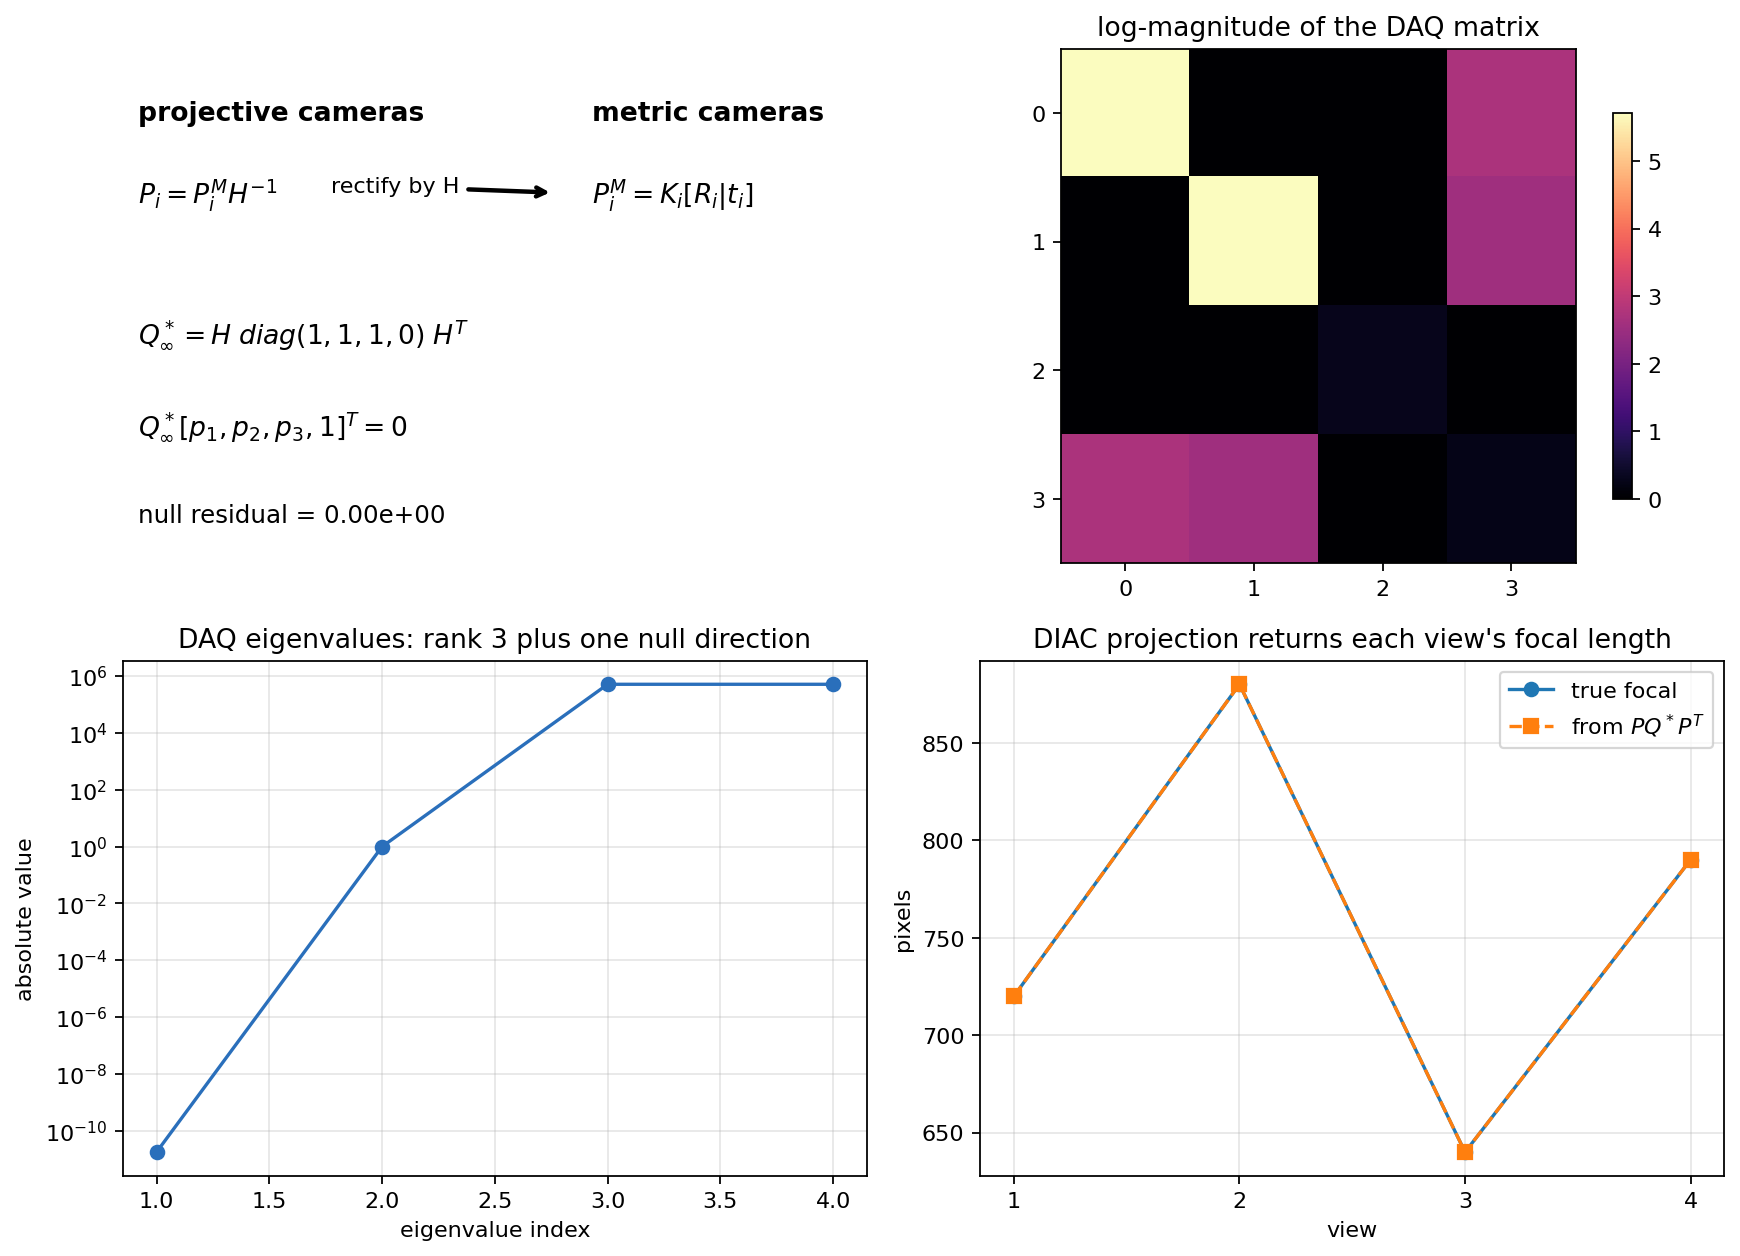

{'plane_at_infinity': [0.001, -0.0007, 0.02, 1.0],
 'daq_eigenvalues': [-1.7616130776386862e-11,
  1.0003999994218342,
  518400.00000000006,
  518400.77241600066],
 'diac_projection_residuals': [0.0,
  1.519394171772906e-16,
  1.0131718462600652e-16,
  1.2759962622322918e-16],
 'recovered_focals_from_diac': [720.0,
  880.0,
  640.0000000000002,
  789.9999999999999]}

In [3]:
focals = np.array([720.0, 880.0, 640.0, 790.0])
rotations = [
    np.eye(3),
    rodrigues([0.2, 1.0, 0.1], 0.35),
    rodrigues([1.0, 0.25, 0.15], -0.28),
    rodrigues([0.3, -0.6, 1.0], 0.42),
]
translations = [
    (0.0, 0.0, 0.0),
    (0.42, 0.04, 0.22),
    (-0.24, 0.10, 0.36),
    (0.18, -0.08, 0.30),
]

K1 = calibration_matrix(focals[0])
p_infinity = np.array([0.0010, -0.0007, 0.0200])
plane_infinity = np.r_[p_infinity, 1.0]
H_rect = rectifier_from_plane_and_K(K1, p_infinity)
Q_true = dual_absolute_quadric(H_rect)

metric_cameras = []
projective_cameras = []
for f, R, t in zip(focals, rotations, translations):
    Ki = calibration_matrix(f)
    PM = camera_matrix(Ki, R, t)
    metric_cameras.append(PM)
    projective_cameras.append(PM @ np.linalg.inv(H_rect))

projected_diacs = [P @ Q_true @ P.T for P in projective_cameras]
expected_diacs = [calibration_matrix(f) @ calibration_matrix(f).T for f in focals]
diac_projection_residuals = [proportional_residual(W, expected)[0] for W, expected in zip(projected_diacs, expected_diacs)]
recovered_focals_from_diac = np.array([math.sqrt(max(0.0, W[0, 0] / W[2, 2])) for W in projected_diacs])

daq_eigenvalues = np.linalg.eigvalsh(Q_true)
daq_null_residual = float(np.linalg.norm(Q_true @ plane_infinity))
first_camera_residual = float(np.linalg.norm(projective_cameras[0] @ H_rect - metric_cameras[0]))

check_data.update({
    "daq_null_residual": daq_null_residual,
    "daq_min_abs_eigenvalue": float(np.min(np.abs(daq_eigenvalues))),
    "daq_rank_numeric": int(np.sum(np.abs(daq_eigenvalues) > 1e-7 * np.max(np.abs(daq_eigenvalues)))),
    "diac_projection_max_residual": float(max(diac_projection_residuals)),
    "rectified_first_camera_residual": first_camera_residual,
})

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
ax = axes[0, 0]
ax.axis("off")
ax.text(0.02, 0.86, "projective cameras", fontsize=12, weight="bold")
ax.text(0.02, 0.70, "$P_i = P^M_i H^{-1}$", fontsize=12)
ax.annotate("rectify by H", xy=(0.58, 0.72), xytext=(0.28, 0.72), arrowprops=dict(arrowstyle="->", lw=2))
ax.text(0.63, 0.86, "metric cameras", fontsize=12, weight="bold")
ax.text(0.63, 0.70, "$P^M_i = K_i[R_i|t_i]$", fontsize=12)
ax.text(0.02, 0.43, "$Q^*_\\infty = H \\; diag(1,1,1,0) \\; H^T$", fontsize=12)
ax.text(0.02, 0.25, "$Q^*_\\infty [p_1,p_2,p_3,1]^T=0$", fontsize=12)
ax.text(0.02, 0.08, f"null residual = {daq_null_residual:.2e}", fontsize=11)

ax = axes[0, 1]
heat = np.log10(np.abs(Q_true) + 1.0)
im = ax.imshow(heat, cmap="magma")
ax.set_title("log-magnitude of the DAQ matrix")
ax.set_xticks(range(4))
ax.set_yticks(range(4))
fig.colorbar(im, ax=ax, shrink=0.75)

ax = axes[1, 0]
ax.semilogy(np.arange(1, 5), np.maximum(np.abs(daq_eigenvalues), 1e-16), marker="o", color="#2a6fbb")
ax.set_title("DAQ eigenvalues: rank 3 plus one null direction")
ax.set_xlabel("eigenvalue index")
ax.set_ylabel("absolute value")
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
view_ids = np.arange(1, len(focals) + 1)
ax.plot(view_ids, focals, "o-", label="true focal")
ax.plot(view_ids, recovered_focals_from_diac, "s--", label="from $P Q^* P^T$")
ax.set_title("DIAC projection returns each view's focal length")
ax.set_xlabel("view")
ax.set_ylabel("pixels")
ax.set_xticks(view_ids)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

daq_path = save_matplotlib(fig, TOPIC, "figures", "absolute-dual-quadric-projection.png")
plt.close(fig)
artifact_paths.append(daq_path)
display_artifact(daq_path, width=900)

{
    "plane_at_infinity": plane_infinity.tolist(),
    "daq_eigenvalues": daq_eigenvalues.tolist(),
    "diac_projection_residuals": diac_projection_residuals,
    "recovered_focals_from_diac": recovered_focals_from_diac.tolist(),
}


## Linear Self-Calibration Constraints For Varying Focal Length

A useful special case is a camera whose principal point is known, skew is zero, aspect ratio is known, and focal length may change from view to view. After shifting the principal point to the origin, each projected DIAC should have the form $diag(f_i^2,f_i^2,1)$ up to scale. That gives four linear constraints per view on the ten homogeneous entries of $Q^*_\infty$: entries $(1,3)$ and $(2,3)$ vanish, entry $(1,2)$ vanishes, and entries $(1,1)$ and $(2,2)$ agree.

The SVD of this stacked system should have a one-dimensional nullspace when enough general views are present. The Plotly artifact then evaluates the residual for candidate focal lengths in each view. The correct focal length is the minimum of the corresponding curve.


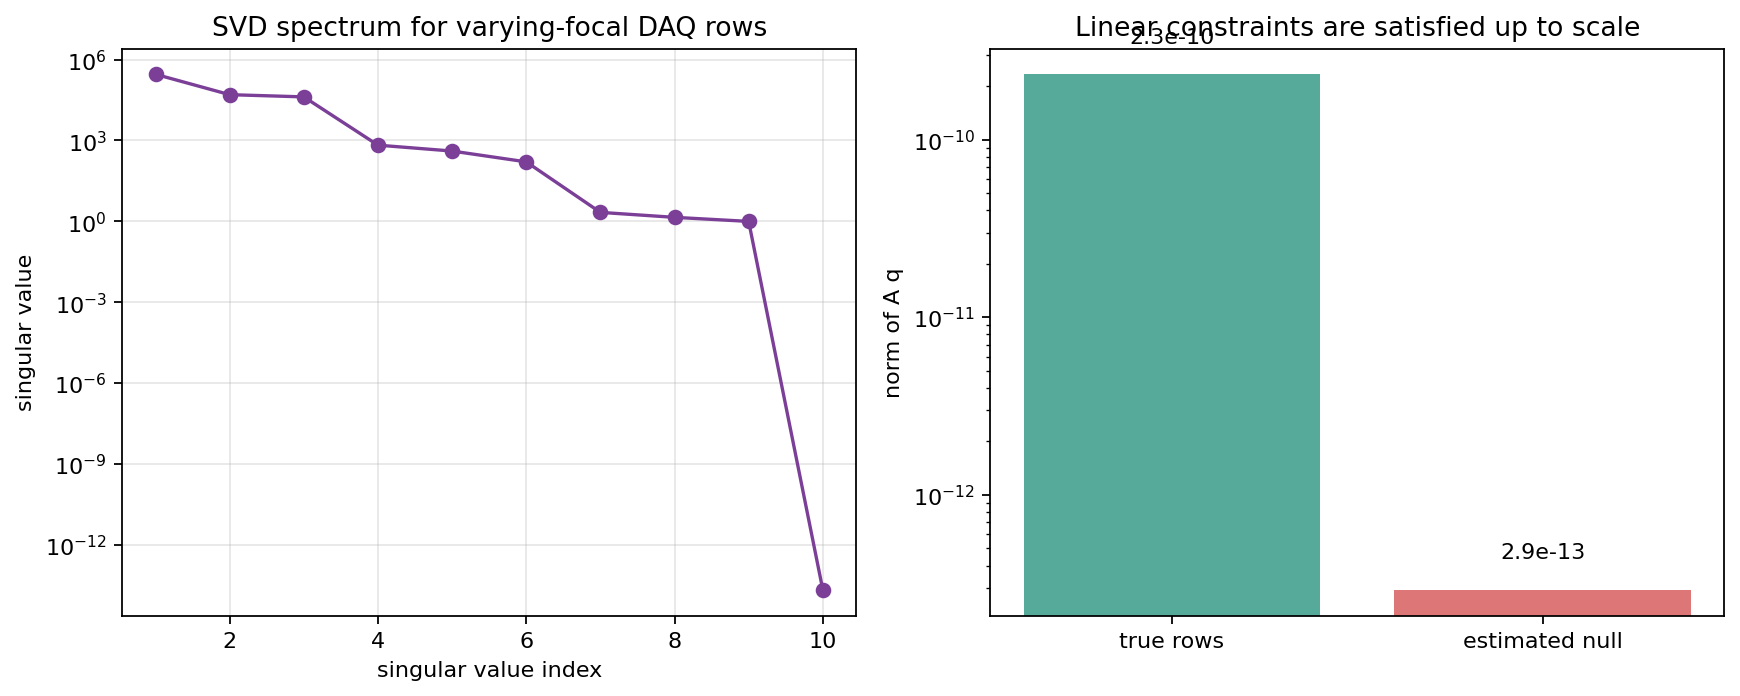

.venv/Lib/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'constraint_matrix_shape': (16, 10),
 'singular_values': [283383.72459579766,
  49808.931610215805,
  41250.393910052604,
  670.2565169075025,
  405.3600482574775,
  160.99663715174637,
  2.160722973808058,
  1.4142150637332693,
  1.000019228946612,
  2.2128662445302938e-14],
 'relative_error_to_known_daq': 6.421899451884358e-14}

In [4]:
Q_est, daq_constraint_matrix, daq_constraint_singular_values = estimate_daq_from_varying_focal(projective_cameras)
scale_to_true = np.sum(Q_true * Q_est) / np.sum(Q_est * Q_est)
Q_est_scaled = scale_to_true * Q_est
daq_estimation_relative_error = float(np.linalg.norm(Q_est_scaled - Q_true) / np.linalg.norm(Q_true))
linear_constraint_residual = float(np.linalg.norm(daq_constraint_matrix @ qvec(Q_est)))
linear_true_residual = float(np.linalg.norm(daq_constraint_matrix @ qvec(Q_true)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].semilogy(np.arange(1, len(daq_constraint_singular_values) + 1), daq_constraint_singular_values, marker="o", color="#7b3f98")
axes[0].set_title("SVD spectrum for varying-focal DAQ rows")
axes[0].set_xlabel("singular value index")
axes[0].set_ylabel("singular value")
axes[0].grid(True, alpha=0.3)

axes[1].bar(["true rows", "estimated null"], [linear_true_residual, linear_constraint_residual], color=["#5a9", "#d77"])
axes[1].set_yscale("log")
axes[1].set_title("Linear constraints are satisfied up to scale")
axes[1].set_ylabel("norm of A q")
for i, val in enumerate([linear_true_residual, linear_constraint_residual]):
    axes[1].text(i, val * 1.5, f"{val:.1e}", ha="center", fontsize=10)
fig.tight_layout()

constraint_path = save_matplotlib(fig, TOPIC, "figures", "varying-focal-linear-daq-constraints.png")
plt.close(fig)
artifact_paths.append(constraint_path)
display_artifact(constraint_path, width=900)

candidate_f = np.linspace(500.0, 1000.0, 260)
plotly_fig = go.Figure()
for idx, (W, f_true) in enumerate(zip(projected_diacs, focals), start=1):
    Wn = W / W[2, 2]
    residuals = []
    for f in candidate_f:
        model = np.diag([f * f, f * f, 1.0])
        residuals.append(np.linalg.norm(Wn - model, ord="fro"))
    plotly_fig.add_trace(go.Scatter(x=candidate_f, y=residuals, mode="lines", name=f"view {idx}: true f={f_true:.0f}"))
    plotly_fig.add_vline(x=float(f_true), line_width=1, line_dash="dot", opacity=0.35)
plotly_fig.update_layout(
    title="Varying focal-length residuals from projected DIACs",
    xaxis_title="candidate focal length in pixels",
    yaxis_title="Frobenius residual to diag(f^2,f^2,1)",
    template="plotly_white",
    width=900,
    height=520,
)

focal_html_path = save_plotly_html(plotly_fig, TOPIC, "interactive", "varying-focal-diac-residuals.html")
artifact_paths.append(focal_html_path)
display_artifact(focal_html_path, width=900, height=560)

check_data.update({
    "varying_focal_constraint_matrix_shape": list(daq_constraint_matrix.shape),
    "varying_focal_svd_nullity": int(np.sum(daq_constraint_singular_values < 1e-10 * daq_constraint_singular_values[0])),
    "varying_focal_linear_constraint_residual": linear_constraint_residual,
    "varying_focal_daq_relative_error": daq_estimation_relative_error,
})

{
    "constraint_matrix_shape": daq_constraint_matrix.shape,
    "singular_values": daq_constraint_singular_values.tolist(),
    "relative_error_to_known_daq": daq_estimation_relative_error,
}


## Kruppa Constraints As Epipolar Tangency

Kruppa equations are two-view constraints. They do not require an explicit projective reconstruction, but they are weaker than knowing the infinite homography. The geometric picture is tangent-line correspondence: an epipolar plane tangent to a 3D conic induces tangent epipolar lines in both images. When the conic is the absolute conic, the algebra is written in terms of the DIAC because tangent lines are dual objects.

The schematic below uses an ordinary visible ellipse so the tangent geometry is inspectable. The numerical check uses the actual Kruppa proportionality for a synthetic constant-calibration camera pair:

$$[e']_x\omega^*[e']_x \sim F\omega^*F^T.$$


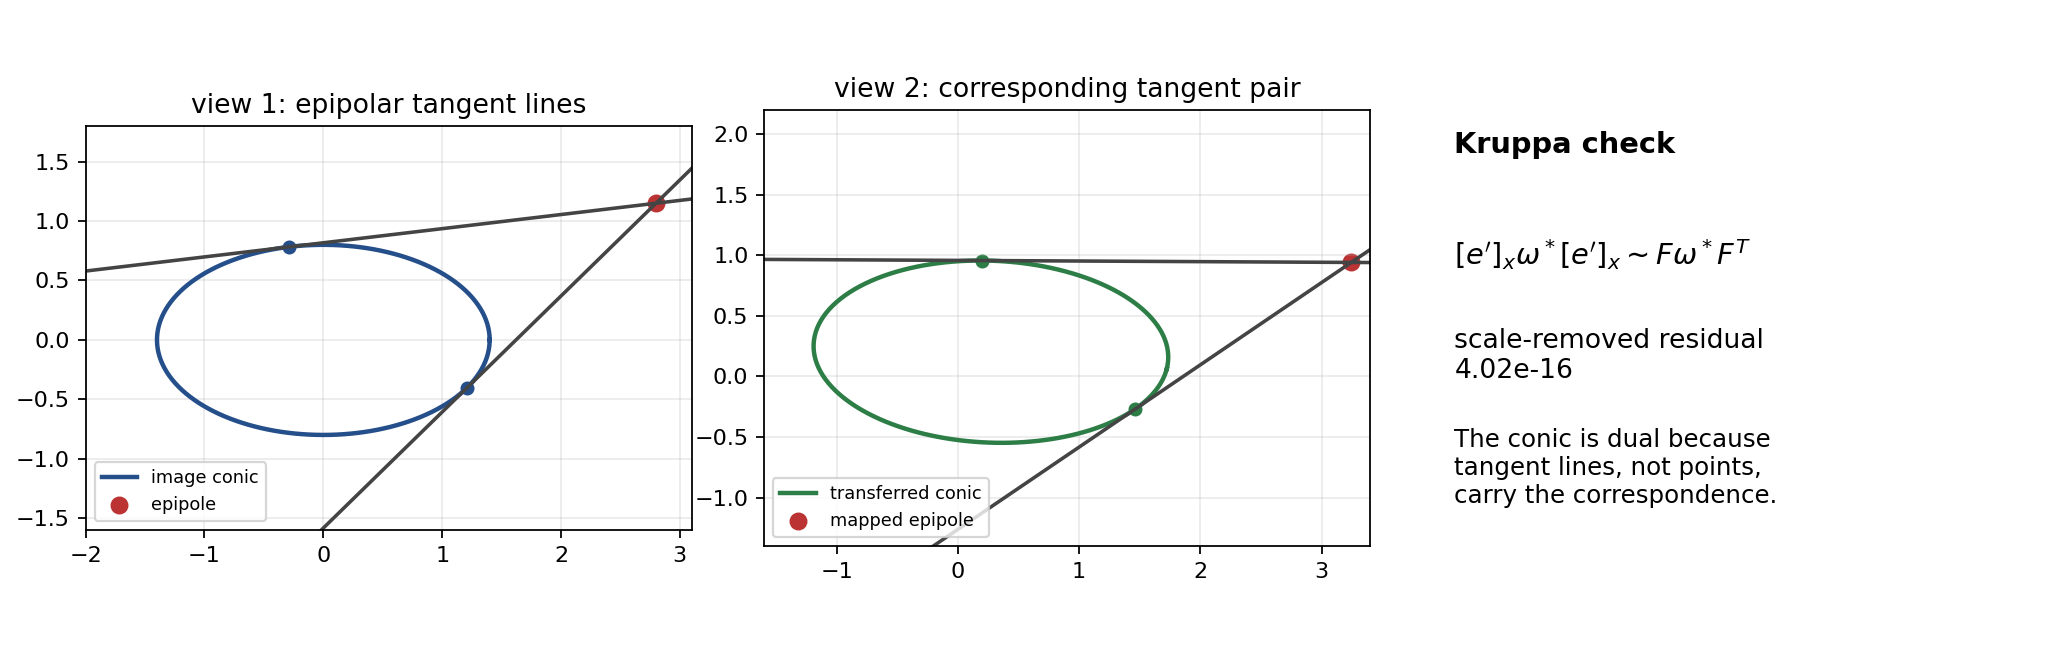

{'kruppa_residual': 4.015505312844483e-16,
 'epipole_second_view': [1670.0000000000011, 240.00000000000006, 1.0]}

In [5]:
def ellipse_points(a, b, center=(0.0, 0.0), samples=300):
    theta = np.linspace(0, 2 * np.pi, samples)
    return np.column_stack([center[0] + a * np.cos(theta), center[1] + b * np.sin(theta), np.ones_like(theta)])


def tangent_points_to_axis_aligned_ellipse(point, a, b, center=(0.0, 0.0)):
    px, py = np.asarray(point[:2], dtype=float) - np.asarray(center, dtype=float)
    A = px / a
    B = py / b
    rho = math.hypot(A, B)
    phi = math.atan2(B, A)
    if rho <= 1.0:
        raise ValueError("point must be outside the ellipse")
    delta = math.acos(1.0 / rho)
    pts = []
    for theta in [phi + delta, phi - delta]:
        pts.append(np.array([center[0] + a * math.cos(theta), center[1] + b * math.sin(theta), 1.0]))
    return pts


ellipse = ellipse_points(1.4, 0.8, center=(0.0, 0.0))
e1 = np.array([2.8, 1.15, 1.0])
tangent_points = tangent_points_to_axis_aligned_ellipse(e1, 1.4, 0.8)
tangent_lines = [np.cross(e1, pt) for pt in tangent_points]
H_plane = np.array([[1.05, 0.18, 0.35], [-0.08, 0.92, 0.18], [0.04, -0.03, 1.0]])
ellipse2_h = (H_plane @ ellipse.T).T
ellipse2 = ellipse2_h[:, :2] / ellipse2_h[:, 2:3]
e2_visual = H_plane @ e1
e2_visual = e2_visual / e2_visual[2]
tangent_points2 = [H_plane @ pt for pt in tangent_points]
tangent_points2 = [pt / pt[2] for pt in tangent_points2]
tangent_lines2 = [np.linalg.inv(H_plane).T @ line for line in tangent_lines]

K_const = calibration_matrix(900.0, 880.0, 320.0, 240.0)
P1 = camera_matrix(K_const, np.eye(3), [0.0, 0.0, 0.0])
P2 = camera_matrix(K_const, rodrigues([0.1, 1.0, 0.2], 0.4), [0.3, 0.0, 0.2])
F = fundamental_from_cameras(P1, P2)
eprime = right_null(F.T)
omega_star = K_const @ K_const.T
kruppa_lhs = skew(eprime) @ omega_star @ skew(eprime).T
kruppa_rhs = F @ omega_star @ F.T
kruppa_residual, kruppa_scale = proportional_residual(kruppa_lhs, kruppa_rhs)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax in axes[:2]:
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)

axes[0].plot(ellipse[:, 0], ellipse[:, 1], color="#254f8a", lw=2, label="image conic")
axes[0].scatter([e1[0]], [e1[1]], color="#b33", s=50, label="epipole")
for line, pt in zip(tangent_lines, tangent_points):
    plot_homogeneous_line(axes[0], line, (-2.0, 3.1), (-1.6, 1.8), color="#444", lw=1.6)
    axes[0].scatter([pt[0]], [pt[1]], color="#254f8a", s=28)
axes[0].set_xlim(-2.0, 3.1)
axes[0].set_ylim(-1.6, 1.8)
axes[0].set_title("view 1: epipolar tangent lines")
axes[0].legend(loc="lower left", fontsize=8)

axes[1].plot(ellipse2[:, 0], ellipse2[:, 1], color="#2d7d46", lw=2, label="transferred conic")
axes[1].scatter([e2_visual[0]], [e2_visual[1]], color="#b33", s=50, label="mapped epipole")
for line, pt in zip(tangent_lines2, tangent_points2):
    plot_homogeneous_line(axes[1], line, (-1.6, 3.4), (-1.4, 2.2), color="#444", lw=1.6)
    axes[1].scatter([pt[0]], [pt[1]], color="#2d7d46", s=28)
axes[1].set_xlim(-1.6, 3.4)
axes[1].set_ylim(-1.4, 2.2)
axes[1].set_title("view 2: corresponding tangent pair")
axes[1].legend(loc="lower left", fontsize=8)

axes[2].axis("off")
axes[2].text(0.02, 0.78, "Kruppa check", fontsize=13, weight="bold")
axes[2].text(0.02, 0.60, "$[e']_x\\omega^*[e']_x \\sim F\\omega^*F^T$", fontsize=13)
axes[2].text(0.02, 0.42, f"scale-removed residual/n{kruppa_residual:.2e}", fontsize=12)
axes[2].text(0.02, 0.22, "The conic is dual because/ntangent lines, not points,/ncarry the correspondence.", fontsize=11)
fig.tight_layout()

kruppa_path = save_matplotlib(fig, TOPIC, "figures", "kruppa-epipolar-tangency.png")
plt.close(fig)
artifact_paths.append(kruppa_path)
display_artifact(kruppa_path, width=920)

check_data.update({
    "kruppa_proportional_residual": kruppa_residual,
    "fundamental_rank": int(np.linalg.matrix_rank(F, tol=1e-9)),
})

{"kruppa_residual": kruppa_residual, "epipole_second_view": eprime.tolist()}


## Stratified IAC Upgrade And Critical Motion Checks

Once the plane at infinity is known, the remaining affine-to-metric step is linear. The infinite homography $H_\infty=A-ap^T$ transfers the IAC by

$$\omega_i = H_\infty^{-T}\omega H_\infty^{-1}.$$

For a camera rotating about its center, the image-to-image homography is already an infinite homography, so the same equation calibrates a rotating camera. The catch is rank. A single rotation axis leaves a one-parameter family of compatible IACs in addition to the unavoidable homogeneous scale. Rotations about different axes remove that ambiguity.


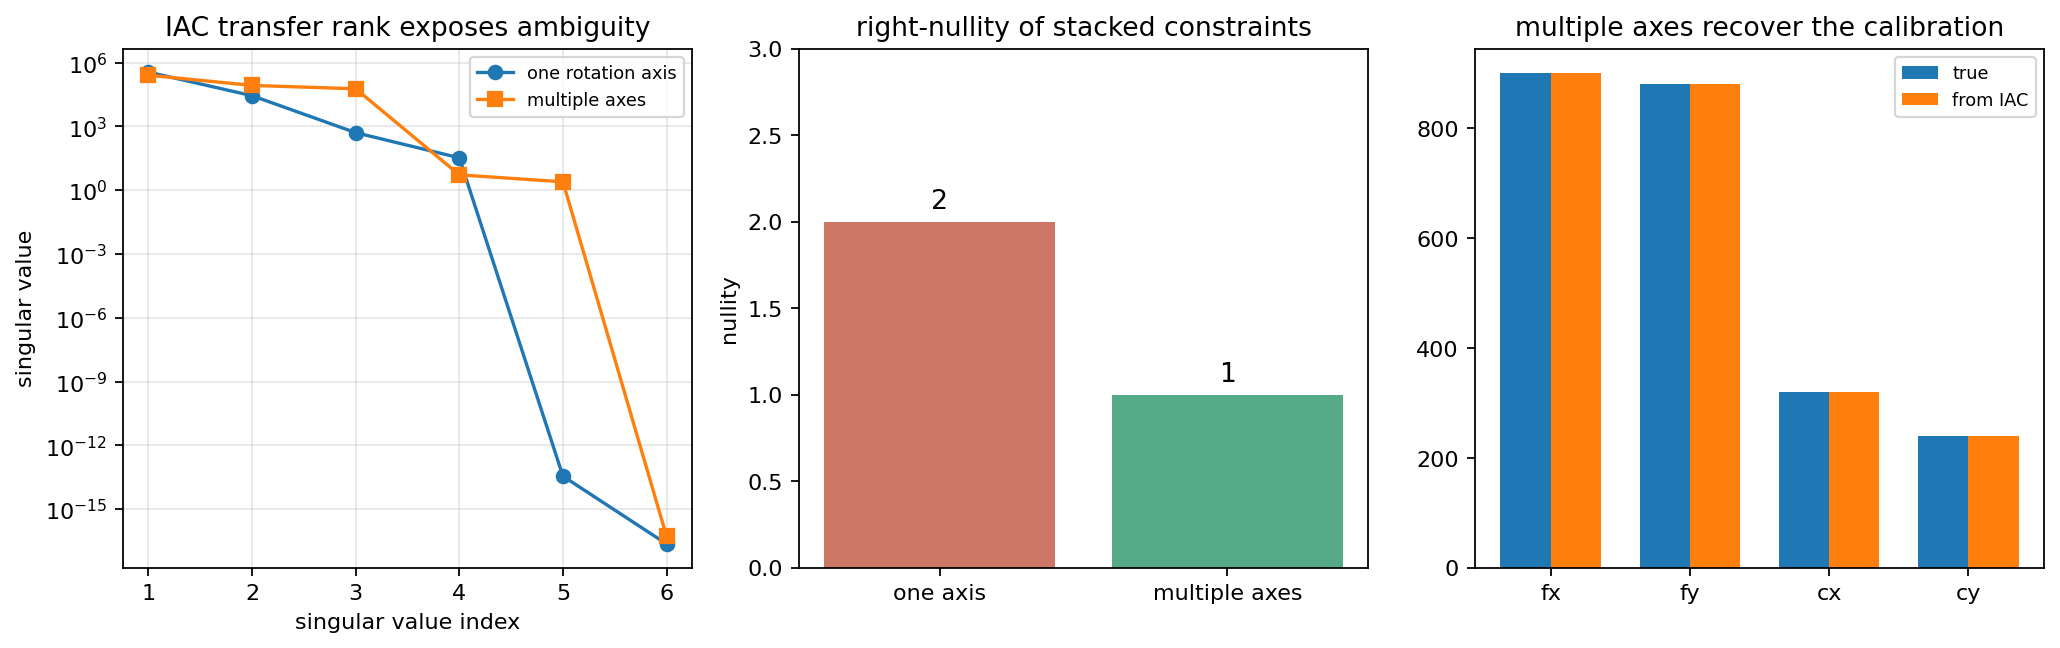

{'K_recovered': [[900.0000000000304, -4.15063145742274e-11, 320.0000000000246],
  [0.0, 879.9999999999742, 239.99999999997047],
  [0.0, 0.0, 1.0]],
 'K_recovery_error': 6.9195370841512e-11}

In [6]:
K_rot = calibration_matrix(900.0, 880.0, 320.0, 240.0)
omega_true = np.linalg.inv(K_rot @ K_rot.T)

one_axis_homographies = [K_rot @ rodrigues([0.0, 1.0, 0.0], angle) @ np.linalg.inv(K_rot) for angle in [0.25, -0.37, 0.58]]
multi_axis_homographies = [
    K_rot @ rodrigues([0.0, 1.0, 0.0], 0.25) @ np.linalg.inv(K_rot),
    K_rot @ rodrigues([1.0, 0.2, 0.4], -0.37) @ np.linalg.inv(K_rot),
    K_rot @ rodrigues([0.3, 0.5, 1.0], 0.58) @ np.linalg.inv(K_rot),
]

omega_one, A_one, s_one = solve_iac_from_homographies(one_axis_homographies)
omega_multi, A_multi, s_multi = solve_iac_from_homographies(multi_axis_homographies)
K_recovered = calibration_from_iac(omega_multi)
K_recovery_error = float(np.linalg.norm(K_recovered - K_rot))
one_axis_nullity = int(np.sum(s_one < 1e-10 * s_one[0]))
multi_axis_nullity = int(np.sum(s_multi < 1e-10 * s_multi[0]))
iac_transfer_residual = float(np.linalg.norm(A_multi @ sym_vec3(omega_true)))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
axes[0].semilogy(np.arange(1, 7), np.maximum(s_one, 1e-18), marker="o", label="one rotation axis")
axes[0].semilogy(np.arange(1, 7), np.maximum(s_multi, 1e-18), marker="s", label="multiple axes")
axes[0].set_title("IAC transfer rank exposes ambiguity")
axes[0].set_xlabel("singular value index")
axes[0].set_ylabel("singular value")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

labels = ["one axis", "multiple axes"]
axes[1].bar(labels, [one_axis_nullity, multi_axis_nullity], color=["#c76", "#5a8"])
axes[1].set_title("right-nullity of stacked constraints")
axes[1].set_ylabel("nullity")
axes[1].set_ylim(0, 3)
for i, val in enumerate([one_axis_nullity, multi_axis_nullity]):
    axes[1].text(i, val + 0.08, str(val), ha="center", fontsize=12)

entries = ["fx", "fy", "cx", "cy"]
true_vals = [K_rot[0, 0], K_rot[1, 1], K_rot[0, 2], K_rot[1, 2]]
rec_vals = [K_recovered[0, 0], K_recovered[1, 1], K_recovered[0, 2], K_recovered[1, 2]]
x = np.arange(len(entries))
axes[2].bar(x - 0.18, true_vals, width=0.36, label="true")
axes[2].bar(x + 0.18, rec_vals, width=0.36, label="from IAC")
axes[2].set_xticks(x, entries)
axes[2].set_title("multiple axes recover the calibration")
axes[2].legend(fontsize=8)
fig.tight_layout()

degeneracy_path = save_matplotlib(fig, TOPIC, "figures", "infinite-homography-degeneracy-spectrum.png")
plt.close(fig)
artifact_paths.append(degeneracy_path)
display_artifact(degeneracy_path, width=920)

check_data.update({
    "one_axis_iac_nullity": one_axis_nullity,
    "multi_axis_iac_nullity": multi_axis_nullity,
    "multi_axis_iac_transfer_residual": iac_transfer_residual,
    "rotating_camera_K_recovery_error": K_recovery_error,
})

{"K_recovered": K_recovered.tolist(), "K_recovery_error": K_recovery_error}


## Stereo Rig: Plane At Infinity From A Projective Motion

For a fixed stereo rig, the scene before and after a rigid rig motion gives two projective reconstructions of the same 3D points in the same projective frame. The projective motion $H_P$ is conjugate to a Euclidean screw motion. Fixed entities of the Euclidean motion become fixed entities of the projective motion. In particular, the plane at infinity is recovered from the nullspace of $H_P^T-I$.

This is also a degeneracy detector. A general screw motion gives one plane-at-infinity eigenvector. If the translation is orthogonal to the rotation axis, the nullspace becomes two-dimensional, so the plane at infinity is not unique without another motion or another constraint.


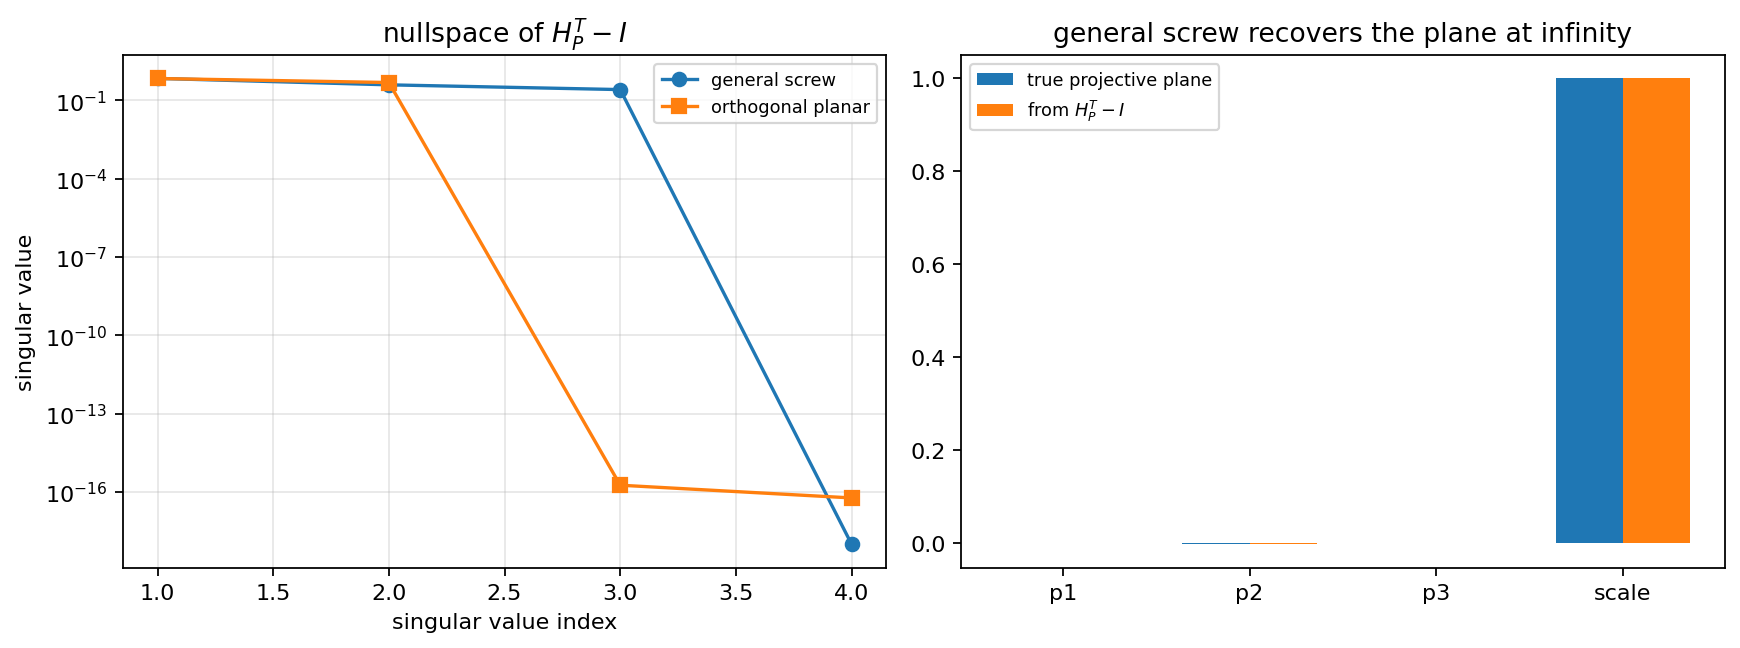

{'plane_projective_est': [0.0009999999999998448,
  -0.0020000000000004016,
  0.0006999999999997722,
  1.0000000000000002],
 'plane_recovery_error': 5.353230522557112e-16}

In [7]:
def projective_motion_from_euclidean(R, t, G):
    HE = np.eye(4)
    HE[:3, :3] = R
    HE[:3, 3] = np.asarray(t, dtype=float)
    return np.linalg.inv(G) @ HE @ G


G_projective_to_euclidean = np.array([
    [1.2, 0.2, -0.1, 0.4],
    [0.05, 0.9, 0.12, -0.2],
    [-0.03, 0.08, 1.1, 0.3],
    [0.001, -0.002, 0.0007, 1.0],
])
plane_E = np.array([0.0, 0.0, 0.0, 1.0])
plane_projective_true = G_projective_to_euclidean.T @ plane_E

HP_general = projective_motion_from_euclidean(rodrigues([0.2, 0.7, 0.3], 0.45), [0.35, 0.12, 0.45], G_projective_to_euclidean)
HP_planar = projective_motion_from_euclidean(rodrigues([0.0, 0.0, 1.0], 0.45), [0.35, 0.12, 0.0], G_projective_to_euclidean)

S_general = np.linalg.svd(HP_general.T - np.eye(4), compute_uv=False)
S_planar = np.linalg.svd(HP_planar.T - np.eye(4), compute_uv=False)
_, _, vt_general = np.linalg.svd(HP_general.T - np.eye(4))
plane_projective_est = vt_general[-1]
plane_projective_est *= np.dot(plane_projective_est, plane_projective_true) / np.dot(plane_projective_est, plane_projective_est)
plane_recovery_error = float(np.linalg.norm(plane_projective_est - plane_projective_true))
stereo_general_nullity = int(np.sum(S_general < 1e-10 * S_general[0]))
stereo_planar_nullity = int(np.sum(S_planar < 1e-10 * S_planar[0]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].semilogy(np.arange(1, 5), np.maximum(S_general, 1e-18), marker="o", label="general screw")
axes[0].semilogy(np.arange(1, 5), np.maximum(S_planar, 1e-18), marker="s", label="orthogonal planar")
axes[0].set_title("nullspace of $H_P^T-I$")
axes[0].set_xlabel("singular value index")
axes[0].set_ylabel("singular value")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

labels = ["p1", "p2", "p3", "scale"]
x = np.arange(4)
axes[1].bar(x - 0.18, plane_projective_true, width=0.36, label="true projective plane")
axes[1].bar(x + 0.18, plane_projective_est, width=0.36, label="from $H_P^T-I$")
axes[1].set_xticks(x, labels)
axes[1].set_title("general screw recovers the plane at infinity")
axes[1].legend(fontsize=8)
fig.tight_layout()

stereo_path = save_matplotlib(fig, TOPIC, "figures", "stereo-rig-plane-at-infinity-eigenvector.png")
plt.close(fig)
artifact_paths.append(stereo_path)
display_artifact(stereo_path, width=900)

check_data.update({
    "stereo_general_plane_nullity": stereo_general_nullity,
    "stereo_planar_motion_nullity": stereo_planar_nullity,
    "stereo_plane_recovery_error": plane_recovery_error,
})

{"plane_projective_est": plane_projective_est.tolist(), "plane_recovery_error": plane_recovery_error}


## Applied Lab: Constraint Counts, Perturbations, And Failure Modes

The chapter repeatedly warns that auto-calibration fails when the motion is too restricted or the constraints are too weak. The table below turns that warning into audit data. It records expected nullities for the synthetic cases already built and adds a small perturbation experiment for the varying-focal DAQ rows. The perturbation is not meant to imitate a full image-noise model; it is a quick conditioning probe. If a tiny matrix perturbation causes a large DAQ change, the calibration should not be trusted without stronger priors or bundle adjustment.


In [8]:
rng = np.random.default_rng(19)
perturbation_rows = []
for sigma in [0.0, 1e-10, 1e-8, 1e-6]:
    noisy_A = daq_constraint_matrix + sigma * rng.normal(size=daq_constraint_matrix.shape)
    _, noisy_s, noisy_vt = np.linalg.svd(noisy_A)
    noisy_Q = qmat(noisy_vt[-1])
    scale = np.sum(Q_true * noisy_Q) / np.sum(noisy_Q * noisy_Q)
    rel_error = np.linalg.norm(scale * noisy_Q - Q_true) / np.linalg.norm(Q_true)
    perturbation_rows.append({
        "row_perturbation_sigma": sigma,
        "smallest_singular_value": float(noisy_s[-1]),
        "second_smallest_singular_value": float(noisy_s[-2]),
        "relative_daq_error": float(rel_error),
    })

critical_motion_rows = [
    {"case": "rotating camera, one axis", "object": "IAC", "expected_meaning": "one ambiguity plus scale", "nullity": one_axis_nullity},
    {"case": "rotating camera, multiple axes", "object": "IAC", "expected_meaning": "scale only", "nullity": multi_axis_nullity},
    {"case": "stereo rig, general screw", "object": "plane at infinity", "expected_meaning": "unique plane", "nullity": stereo_general_nullity},
    {"case": "stereo rig, planar orthogonal motion", "object": "plane at infinity", "expected_meaning": "one-parameter plane ambiguity", "nullity": stereo_planar_nullity},
]

critical_path = save_csv(critical_motion_rows, TOPIC, "tables", "critical-motion-nullities.csv")
artifact_paths.append(critical_path)
display_artifact(critical_path)

perturbation_path = save_csv(perturbation_rows, TOPIC, "tables", "varying-focal-perturbation-audit.csv")
artifact_paths.append(perturbation_path)
display_artifact(perturbation_path)

pd.DataFrame(critical_motion_rows)


[critical-motion-nullities.csv](artifacts/chapter-19/tables/critical-motion-nullities.csv)

[varying-focal-perturbation-audit.csv](artifacts/chapter-19/tables/varying-focal-perturbation-audit.csv)

,case,object,expected_meaning,nullity
0,"rotating camera, one axis",IAC,one ambiguity plus scale,2
1,"rotating camera, multiple axes",IAC,scale only,1
2,"stereo rig, general screw",plane at infinity,unique plane,1
3,"stereo rig, planar orthogonal motion",plane at infinity,one-parameter plane ambiguity,2


## Exact Null-Vector Scaffold

The DAQ null-vector statement is short enough to verify symbolically. With $K=diag(f_x,f_y,1)$ only to keep the expression compact, the rectifier still has the chapter's block form. SymPy confirms that $Q^*_\infty[p_1,p_2,p_3,1]^T$ is exactly zero, not merely numerically small.


In [9]:
px, py, pz, fx, fy = sp.symbols("px py pz fx fy", nonzero=True)
K_symbolic = sp.diag(fx, fy, 1)
H_symbolic = sp.eye(4)
H_symbolic[:3, :3] = K_symbolic
H_symbolic[3, :3] = -(sp.Matrix([[px, py, pz]]) * K_symbolic)
Q_symbolic = H_symbolic * sp.diag(1, 1, 1, 0) * H_symbolic.T
plane_symbolic = sp.Matrix([px, py, pz, 1])
symbolic_daq_null = [sp.simplify(entry) for entry in Q_symbolic * plane_symbolic]
check_data["symbolic_daq_null_identity"] = [str(entry) for entry in symbolic_daq_null]
symbolic_daq_null


[0, 0, 0, 0]

## Final Sanity Checks

The final cell writes a single invariant JSON file and asserts the chapter's core computational claims. The tolerances are tight because the data are deterministic and noise-free except for the explicit perturbation audit. In a real image sequence the same checks would be used with looser thresholds and with bundle adjustment residuals added to the report.


In [10]:
check_data.update({
    "artifact_count": len(artifact_paths),
    "artifact_paths": [path.relative_to(BOOK_ROOT).as_posix() for path in artifact_paths],
    "varying_focal_true_focals": focals.tolist(),
    "varying_focal_recovered_focals_from_diac": recovered_focals_from_diac.tolist(),
    "perturbation_audit": perturbation_rows,
    "critical_motion_nullities": critical_motion_rows,
})

final_sanity = check_data
checks_path = save_json(check_data, TOPIC, "checks", "auto-calibration-invariants.json")
artifact_paths.append(checks_path)
display_artifact(checks_path)

assert_artifacts(artifact_paths, min_bytes=200)
assert check_data["daq_rank_numeric"] == 3
assert check_data["daq_null_residual"] < 1e-7
assert check_data["diac_projection_max_residual"] < 1e-12
assert check_data["varying_focal_svd_nullity"] == 1
assert check_data["varying_focal_daq_relative_error"] < 1e-9
assert check_data["kruppa_proportional_residual"] < 1e-10
assert check_data["one_axis_iac_nullity"] == 2
assert check_data["multi_axis_iac_nullity"] == 1
assert check_data["rotating_camera_K_recovery_error"] < 1e-6
assert check_data["stereo_general_plane_nullity"] == 1
assert check_data["stereo_planar_motion_nullity"] == 2
assert check_data["stereo_plane_recovery_error"] < 1e-10
assert check_data["symbolic_daq_null_identity"] == ["0", "0", "0", "0"]

check_data


`artifacts/chapter-19/checks/auto-calibration-invariants.json`

{'daq_null_residual': 0.0,
 'daq_min_abs_eigenvalue': 1.7616130776386862e-11,
 'daq_rank_numeric': 3,
 'diac_projection_max_residual': 1.519394171772906e-16,
 'rectified_first_camera_residual': 0.0,
 'varying_focal_constraint_matrix_shape': [16, 10],
 'varying_focal_svd_nullity': 1,
 'varying_focal_linear_constraint_residual': 2.921002651724076e-13,
 'varying_focal_daq_relative_error': 6.421899451884358e-14,
 'kruppa_proportional_residual': 4.015505312844483e-16,
 'fundamental_rank': 2,
 'one_axis_iac_nullity': 2,
 'multi_axis_iac_nullity': 1,
 'multi_axis_iac_transfer_residual': 4.0792212703646976e-16,
 'rotating_camera_K_recovery_error': 6.9195370841512e-11,
 'stereo_general_plane_nullity': 1,
 'stereo_planar_motion_nullity': 2,
 'stereo_plane_recovery_error': 5.353230522557112e-16,
 'symbolic_daq_null_identity': ['0', '0', '0', '0'],
 'artifact_count': 8,
 'artifact_paths': ['artifacts/chapter-19/figures/absolute-dual-quadric-projection.png',
  'artifacts/chapter-19/figures/varying-

## Takeaways

- Auto-calibration is a metric upgrade problem: identify the plane at infinity and the absolute conic, or package both in the DAQ.
- The DAQ projection identity $P Q^*_\infty P^T=\omega^*$ converts camera-internal assumptions into linear or nonlinear constraints on a single 3D quadric.
- Varying focal length is not a side case; it is a useful test of whether the notebook keeps per-view calibration separate from fixed geometric structure.
- Kruppa constraints are two-view dual-conic constraints. They are valuable when only a fundamental matrix is available, but they do not enforce all multiview DAQ structure.
- Stratified calibration is easier after the plane at infinity is known because IAC transfer through the infinite homography is linear.
- Degeneracy is visible as extra nullity. One rotation axis, planar rig motion, pure translations, and turntable-style restrictions leave metric quantities that the images cannot determine without extra assumptions.
